# GT Rotation Difference Histogram — Boreas 2D

Aggregated histogram of the **ground-truth rotation difference** between paired
radar scans of the `boreas2d` 3-step **non-rotation** benchmark set.

- **Data**: `…/allDatasets/3stepNonRotation/boreas2d/`
- **Scope**: all 45 sequences (seq00–seq44), one single histogram
- **Pairs**: scans `matching_step = 3` apart, **no** extra random rotation applied
- **Per pair**: `gt_rot_deg` = signed yaw difference [deg] from the Boreas GT poses
  (read from the per-sequence `results.csv`; GT is *method-independent*, so all
  method folders hold the same GT and we deduplicate pairs)

Run with the `ml` conda env: `~/.conda/envs/ml/bin/jupyter-lab`

In [1]:
%matplotlib inline

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("python:", sys.version.split()[0])
print("pandas:", pd.__version__)

# Root of the boreas2d 3-step (non-rotation) benchmark results
DATA_DIR = (
    Path.home()
    / "ros_ws"
    / "src"
    / "fsregistration"
    / "pythonScripts"
    / "radarDataset"
    / "2D_registration_results"
    / "allDatasets"
    / "3stepNonRotation"
    / "boreas2d"
)
print("DATA_DIR exists:", DATA_DIR.exists())
print("DATA_DIR:", DATA_DIR)

python: 3.12.13
pandas: 3.0.5
DATA_DIR exists: True
DATA_DIR: /home/tim-external/ros_ws/src/fsregistration/pythonScripts/radarDataset/2D_registration_results/allDatasets/3stepNonRotation/boreas2d


## 1. Load ground-truth rotations

Each pair's GT rotation is identical across the 10 method folders, so we scan
every folder and deduplicate by `(sequence, prev_frame, curr_frame)`.

In [2]:
seq_dirs = sorted(p for p in DATA_DIR.iterdir() if p.is_dir() and p.name.startswith("seq"))

frames = []
for d in seq_dirs:
    seq = d.name.split("_")[0]
    f = d / "results.csv"
    if not f.exists():
        continue
    df = pd.read_csv(f, comment="#", usecols=["prev_frame", "curr_frame", "gt_rot_deg"])
    df["sequence"] = seq
    frames.append(df)

df_gt = pd.concat(frames, ignore_index=True)
df_gt = df_gt.drop_duplicates(subset=["sequence", "prev_frame", "curr_frame"])
df_gt["abs_rot_deg"] = df_gt["gt_rot_deg"].abs()
df_gt = df_gt.sort_values(["sequence", "prev_frame"]).reset_index(drop=True)

print(f"Sequences used:          {df_gt['sequence'].nunique()}")
print(f"Sequence folders scanned:{len(seq_dirs)}")
print(f"Total GT pairs (unique): {len(df_gt):,}")
df_gt.head()

Sequences used:          45
Sequence folders scanned:450
Total GT pairs (unique): 64,984


,prev_frame,curr_frame,gt_rot_deg,sequence,abs_rot_deg
0,0,3,-0.002200,seq00,0.002200
1,3,6,0.001408,seq00,0.001408
2,6,9,0.002996,seq00,0.002996
3,9,12,-0.001113,seq00,0.001113
4,12,15,0.001983,seq00,0.001983


## 2. Summary statistics (whole dataset)

In [3]:
gt = df_gt["gt_rot_deg"]
ab = df_gt["abs_rot_deg"]

stats = pd.Series({
    "total_pairs": len(df_gt),
    "signed_mean_deg": gt.mean(),
    "signed_median_deg": gt.median(),
    "abs_mean_deg": ab.mean(),
    "abs_median_deg": ab.median(),
    "abs_std_deg": ab.std(),
    "abs_p90_deg": ab.quantile(0.90),
    "abs_p99_deg": ab.quantile(0.99),
    "abs_max_deg": ab.max(),
    "abs_<_0.5_deg_%": 100 * (ab < 0.5).mean(),
    "0.5_<=_abs_<_1_deg_%": 100 * ((ab >= 0.5) & (ab < 1)).mean(),
    "1_<=_abs_<_5_deg_%": 100 * ((ab >= 1) & (ab < 5)).mean(),
    "abs_>=_5_deg_%": 100 * (ab >= 5).mean(),
}).round(4)
print(stats.to_string())

total_pairs             64984.0000
signed_mean_deg             0.0037
signed_median_deg           0.0000
abs_mean_deg                1.3685
abs_median_deg              0.0905
abs_std_deg                 3.3414
abs_p90_deg                 3.6507
abs_p99_deg                17.2293
abs_max_deg                40.4971
abs_<_0.5_deg_%            67.5920
0.5_<=_abs_<_1_deg_%        7.2310
1_<=_abs_<_5_deg_%         18.2029
abs_>=_5_deg_%              6.9740


## 3. Absolute GT rotation difference — main histogram

All 45 sequences together. Most Boreas pairs are near-straight driving
($|\Delta\theta| < 0.5°$ for ~68% of pairs), so a **log y-axis** is used to show
the tail of turns up to ~40°.

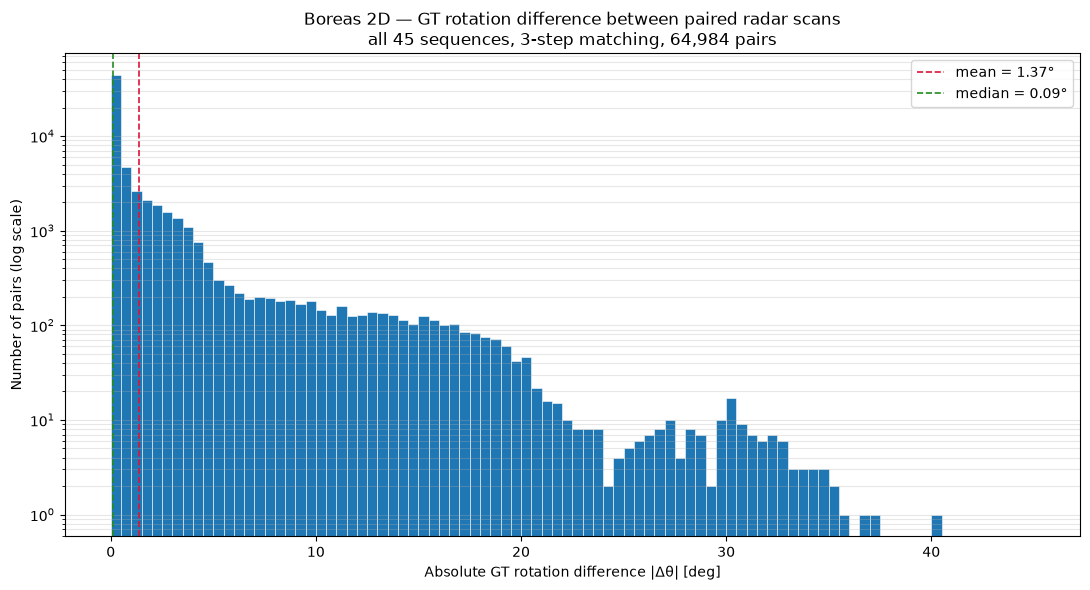

In [4]:
bins = np.arange(0, 45.5, 0.5)

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(ab, bins=bins, color="#1f77b4", edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xlabel("Absolute GT rotation difference |Δθ| [deg]")
ax.set_ylabel("Number of pairs (log scale)")
ax.set_title("Boreas 2D — GT rotation difference between paired radar scans\n"
             f"all 45 sequences, 3-step matching, {len(df_gt):,} pairs")
ax.axvline(ab.mean(), color="crimson", ls="--", lw=1.2, label=f"mean = {ab.mean():.2f}°")
ax.axvline(ab.median(), color="forestgreen", ls="--", lw=1.2, label=f"median = {ab.median():.2f}°")
ax.grid(axis="y", which="both", alpha=0.3)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

Zoomed view of the 0–5° range (linear y-axis), which contains ~97% of the pairs.

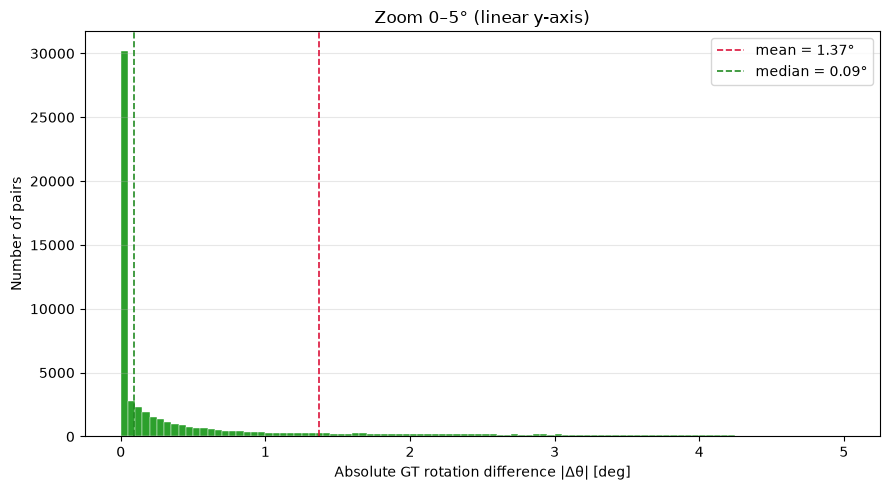

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ab[ab <= 5], bins=np.arange(0, 5.05, 0.05), color="#2ca02c",
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("Absolute GT rotation difference |Δθ| [deg]")
ax.set_ylabel("Number of pairs")
ax.set_title("Zoom 0–5° (linear y-axis)")
ax.axvline(ab.mean(), color="crimson", ls="--", lw=1.2, label=f"mean = {ab.mean():.2f}°")
ax.axvline(ab.median(), color="forestgreen", ls="--", lw=1.2, label=f"median = {ab.median():.2f}°")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Signed GT rotation difference (secondary)

Positive = counter-clockwise (left), negative = clockwise (right). The
near-symmetric distribution confirms the dataset is dominated by straight
driving with balanced turns.

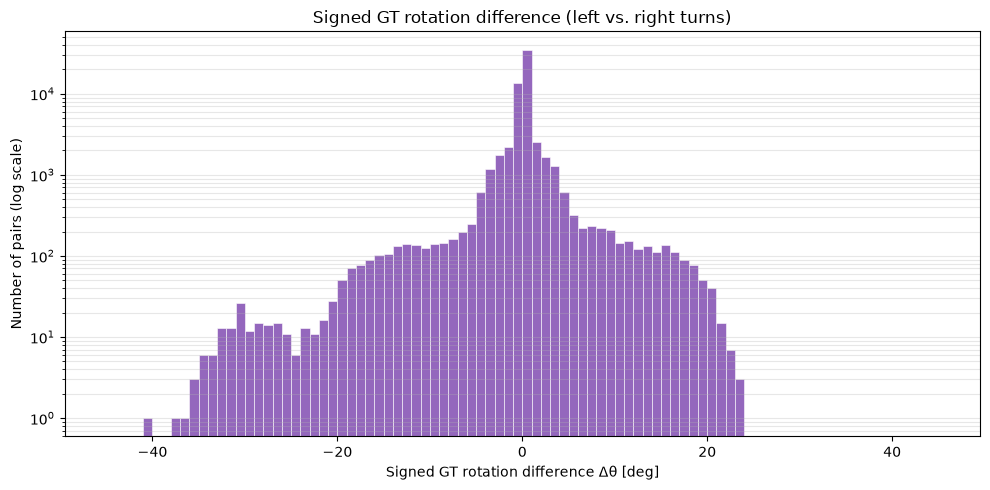

In [6]:
bins_signed = np.arange(-45, 45.5, 1.0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gt, bins=bins_signed, color="#9467bd", edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xlabel("Signed GT rotation difference Δθ [deg]")
ax.set_ylabel("Number of pairs (log scale)")
ax.set_title("Signed GT rotation difference (left vs. right turns)")
ax.grid(axis="y", which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Per-sequence overview (for reference)

In [7]:
seq_stats = df_gt.groupby("sequence").agg(
    pairs=("abs_rot_deg", "size"),
    mean_deg=("abs_rot_deg", "mean"),
    median_deg=("abs_rot_deg", "median"),
    max_deg=("abs_rot_deg", "max"),
).round(3)
seq_stats

,pairs,mean_deg,median_deg,max_deg
sequence,,,,
seq00,1380,2.041,0.467,33.793
seq01,1282,2.157,0.526,30.393
seq02,1643,0.000,0.000,0.000
seq03,1328,2.206,0.575,32.095
seq04,1236,2.304,0.648,31.978
seq05,1259,2.175,0.520,32.513
seq06,1640,0.000,0.000,0.000
seq07,1883,1.449,0.311,20.626
seq08,1474,1.881,0.381,30.481


### Interpretation

- The histogram is the **aggregation over all 45 sequences** of the GT rotation
  between every scan pair (3 frames apart) — a single dataset-level histogram.
- The bulk of the mass sits near $0°$ (straight driving): median $|Δθ| \approx 0.09°$,
  ~68% of pairs $< 0.5°$.
- The tail extends to ~40° for the turns. This range is valuable context for the
  registration benchmark: most pairs are near-identity rotations, with a long tail
  of genuine turns the methods must handle.